# 4a_QRF_MODEL_TARGET — Merged QRF Training, Artefact Export & Target Prediction

This notebook merges **4a_QRF_MODEL** (training & diagnostics) and **5a_QRF_TARGETS** (grid prediction & netCDF export) into a single workflow. Imports and constants are consolidated at the top; all figure generation, diagnostic files, and model artefacts are preserved.


## 0. Consolidated imports & constants


In [ ]:
# ── Consolidated imports & constants (merged from 4a_QRF_MODEL and 5a_QRF_TARGETS) ──
import sys, json, pickle, time, warnings, datetime
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from pyproj import Transformer
from scipy.interpolate import PchipInterpolator
from scipy.stats import entropy as scipy_entropy
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')

# ── paths (from 4a) ──────────────────────────────────────────────────────────
local_data = Path('data')
param_dir  = Path('output/sweeps')
model_dir  = Path('output/models')
fig_dir    = Path('fig/models')
model_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

# ── shared constants (from 4a) ───────────────────────────────────────────────
TEST_FRAC       = 0.20
RANDOM_SEED     = 42
TARGET_COL      = 'q'
Q_CLIP_MIN      = 0.0
QUANTILES       = [0.05, 0.25, 0.50, 0.75, 0.95]
QUANTILES_DENSE = np.linspace(0.02, 0.98, 49).tolist()
HIST_BIN_W      = 0.010
CONFORMAL_ALPHA = 0.10
SPLINE_PCTLS    = 200   # number of percentile knots for correction spline
FIG_DPI         = 150

# ── config imports (union of 4a + 5a) ────────────────────────────────────────
from config import obs_model, q_clip_max, random_state
from config import *   # brings in targets_dir, param_paths, PRED_QUANTILES, MODEL_VERSION, etc.

targets_dir.mkdir(parents=True, exist_ok=True)
Q50_IDX = QUANTILES.index(0.50)

print(f'obs_model features : {len(obs_model)}')
print(f'q_clip_max         : {q_clip_max} W/m²')
print(f'Test fraction      : {TEST_FRAC}')
print(f'quantiles          : {QUANTILES}')
print(f'model version      : {MODEL_VERSION}')
print(f'targets_dir        : {targets_dir}')


---

# Part 1 — 4a_QRF_MODEL: QRF Training & Artefact Export


## 2. Load reference data

In [5]:
df = pd.read_parquet(local_data / 'IHFC_obs.parquet').copy()
print(f'Raw rows: {len(df)}')

df = df.dropna(subset=obs_model)
print(f'After dropna : {len(df)} rows')

if 'weight' in df.columns:
    w_all = df['weight'].values.astype(np.float32)
    w_all = w_all / w_all.mean()
    print(f'Weights  min={w_all.min():.4f}  max={w_all.max():.4f}  mean={w_all.mean():.4f}')
else:
    w_all = np.ones(len(df), dtype=np.float32)
    print('WARNING: no weight column — using uniform weights')


Raw rows: 30848
After dropna : 30847 rows
Weights  min=0.1123  max=3.5262  mean=1.0000


## 3. Load sweep parameters

In [6]:
from quantile_forest import RandomForestQuantileRegressor

with open(param_dir / 'qrf_params.json') as fp:
    PARAMS = json.load(fp)

# obs_sel: use features stored in JSON (from sweep), fall back to obs_model
obs_sel = PARAMS.get('features', obs_model)
print(f'Loaded qrf_params.json')
print(f'  obs_sel ({len(obs_sel)} features): {obs_sel}')
print(f'  n_estimators     : {PARAMS["n_estimators"]}')
print(f'  max_depth        : {PARAMS["max_depth"]}')
print(f'  min_samples_leaf : {PARAMS["min_samples_leaf"]}')
print(f'  max_features     : {PARAMS["max_features"]}')


Loaded qrf_params.json
  obs_sel (21 features): ['MOHO', 'MOHO_GRAV', 'DEM', 'LAB', 'FREE_AIR', 'BOUGUER', 'SI', 'GEOID', 'REVEAL_S80', 'REVEAL_S90', 'REVEAL_S70', 'REVEAL_S100', 'REVEAL_VP60VS70', 'REVEAL_VP90VS60', 'REVEAL_VP50VS80', 'LITH_RHO', 'CRUST_RHO', 'MAG_SEIS_MOHO', 'SEDIMENT', 'CTD', 'EMAG2_LOG']
  n_estimators     : 1000
  max_depth        : 50
  min_samples_leaf : 3
  max_features     : 0.7


## 4. Train/test split & StandardScaler

In [7]:
X_all = df[obs_sel].values.astype(np.float32)
y_all = df[TARGET_COL].values.astype(np.float32)

assert np.isfinite(X_all).all(), 'NaNs in X_all — check obs_sel'
assert np.isfinite(y_all).all(), 'NaNs in y_all'

X_tr_raw, X_te_raw, y_tr, y_te, w_tr, w_te = train_test_split(
    X_all, y_all, w_all, test_size=TEST_FRAC, random_state=RANDOM_SEED)

scaler = StandardScaler().fit(X_tr_raw)
X_tr   = scaler.transform(X_tr_raw).astype(np.float32)
X_te   = scaler.transform(X_te_raw).astype(np.float32)

# Held-out calibration slice (last 10 % of train — no additional leakage)
cal_frac = float(PARAMS.get('cal_frac', 0.10))
n_cal    = max(int(len(X_tr) * cal_frac), 100)
X_cal, y_cal, w_cal = X_tr[-n_cal:], y_tr[-n_cal:], w_tr[-n_cal:]

print(f'Train  : {len(y_tr):,}    Test : {len(y_te):,}    Cal slice : {n_cal:,}')
print(f'Features used : {len(obs_sel)}')


Train  : 24,677    Test : 6,170    Cal slice : 2,467
Features used : 21


## 5. Fit QRF

Loads from pickle if `qrf_model.pkl` already exists.
Safe to re-run — will not re-train unnecessarily.

In [8]:
qrf_path = model_dir / 'qrf_model.pkl'
t0 = time.time()

if qrf_path.exists():
    print('QRF: loading saved model …')
    with open(qrf_path, 'rb') as fp:
        qrf = pickle.load(fp)
else:
    print('QRF: training …')
    qrf = RandomForestQuantileRegressor(
        n_estimators     = int(PARAMS['n_estimators']),
        max_depth        = PARAMS['max_depth'] if str(PARAMS['max_depth']) != 'None' else None,
        min_samples_leaf = int(PARAMS['min_samples_leaf']),
        max_features     = PARAMS['max_features'],
        n_jobs           = -1,
        random_state     = RANDOM_SEED,
    )
    nan_mask = ~np.isfinite(X_tr).all(axis=1)
    if nan_mask.any():
        print(f'  WARNING: dropping {nan_mask.sum()} NaN rows before fit')
    Xf, yf, wf = X_tr[~nan_mask], y_tr[~nan_mask], w_tr[~nan_mask]
    qrf.fit(Xf, yf, sample_weight=wf)
    with open(qrf_path, 'wb') as fp:
        pickle.dump(qrf, fp)
    print(f'  saved → {qrf_path}')

print(f'Wall time: {(time.time()-t0)/60:.1f} min')


QRF: training …
  saved → output/models/qrf_model.pkl
Wall time: 0.8 min


## 6. Test-set predictions + conformal calibration

Conformal scores computed on the held-out calibration slice;
`qhat` adjusts the PI bounds to achieve the requested coverage.

In [9]:
print('Predicting on test set …')
qrf_preds = qrf.predict(X_te, quantiles=QUANTILES)           # (n, 5)
qrf_dense = qrf.predict(X_te, quantiles=QUANTILES_DENSE)     # (n, 49)
qrf_q50   = qrf_preds[:, QUANTILES.index(0.50)]
qrf_q05   = qrf_preds[:, QUANTILES.index(0.05)]
qrf_q95   = qrf_preds[:, QUANTILES.index(0.95)]
qrf_mean  = qrf_dense.mean(axis=1)
qrf_std   = qrf_dense.std(axis=1)

# conformal calibration
cal_out    = qrf.predict(X_cal, quantiles=[0.05, 0.95])
cal_q05_qrf, cal_q95_qrf = cal_out[:, 0], cal_out[:, 1]
scores_qrf = np.maximum(cal_q05_qrf - y_cal, y_cal - cal_q95_qrf)
qhat_qrf   = np.quantile(scores_qrf,
                         (1 - CONFORMAL_ALPHA) * (1 + 1 / len(scores_qrf)))
qrf_conf_lo = np.clip(qrf_q05 - qhat_qrf, Q_CLIP_MIN, None)
qrf_conf_hi = np.clip(qrf_q95 + qhat_qrf, None, q_clip_max)
print(f'Conformal qhat = {qhat_qrf*1e3:.2f} mW/m²')


Predicting on test set …
Conformal qhat = -3.00 mW/m²


## 7. Correction spline helpers

In [10]:
def weighted_percentile(vals, weights, pcts):
    """Weighted quantile (ignores NaN/inf)."""
    mask = np.isfinite(vals) & np.isfinite(weights)
    vs, ws = vals[mask], weights[mask]
    idx  = np.argsort(vs)
    cumw = np.cumsum(ws[idx]) / ws.sum()
    return np.interp(pcts / 100.0, cumw, vs[idx])

def build_correction_spline(y_pred_cal, y_true_cal, w_cal, n_pctls=SPLINE_PCTLS):
    """
    PCHIP spline mapping model predictions → empirical reference distribution.
    Fitted on calibration slice only (no test leakage).
    Addresses regression-to-the-mean / centre-of-distribution bias.
    """
    pctls      = np.linspace(1, 99, n_pctls)
    pred_p     = weighted_percentile(y_pred_cal, w_cal, pctls)
    true_p     = weighted_percentile(y_true_cal, w_cal, pctls)
    _, keep    = np.unique(pred_p, return_index=True)
    spline     = PchipInterpolator(pred_p[keep], true_p[keep], extrapolate=True)
    return spline, pred_p, true_p

def apply_spline(vals, spline):
    out    = np.full_like(vals, np.nan, dtype=np.float32)
    ok     = np.isfinite(vals)
    out[ok] = np.clip(spline(vals[ok]).astype(np.float32), Q_CLIP_MIN, q_clip_max)
    return out

print('Spline helpers defined.')


Spline helpers defined.


## 7a. Fit & apply correction spline

PCHIP monotone interpolation from predicted percentiles → observed
percentiles (both weighted). Corrects regression-to-the-mean bias.
Fitted exclusively on the calibration slice to avoid test leakage.

Fitting correction spline on calibration set …


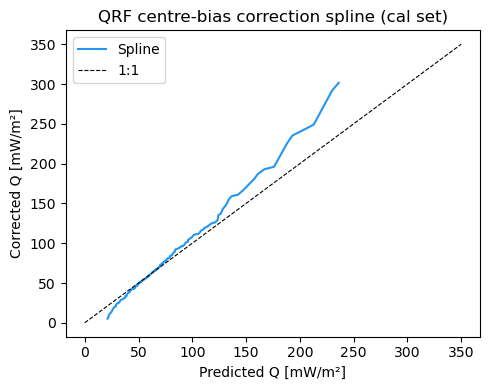

Saved fig/models/qrf_correction_spline.png


In [ ]:
print('Fitting correction spline on calibration set …')
cal_q50_raw = qrf.predict(X_cal, quantiles=[0.50])
if cal_q50_raw.ndim == 2: cal_q50_raw = cal_q50_raw[:, 0]

qrf_spline, qrf_pred_p, qrf_true_p = build_correction_spline(
    cal_q50_raw, y_cal, w_cal)



# apply to test set
qrf_q50_corr   = apply_spline(qrf_q50, qrf_spline)
qrf_q05_corr   = apply_spline(qrf_q05, qrf_spline)
qrf_q95_corr   = apply_spline(qrf_q95, qrf_spline)
qrf_mean_corr  = apply_spline(qrf_mean, qrf_spline)

# spline plot
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(qrf_pred_p*1e3, qrf_true_p*1e3, lw=1.5, color='#2196F3', label='Spline')
ax.plot([0, q_clip_max*1e3], [0, q_clip_max*1e3], 'k--', lw=0.8, label='1:1')
ax.set_xlabel('Predicted Q [mW/m²]'); ax.set_ylabel('Corrected Q [mW/m²]')
ax.set_title('QRF centre-bias correction spline (cal set)')
ax.legend(); fig.tight_layout()
fig.savefig(fig_dir / 'qrf_correction_spline.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show(); print(f'Saved {fig_dir}/qrf_correction_spline.png')


## 8. Metrics

In [12]:
def empirical_entropy(vals, bin_width=HIST_BIN_W):
    bins   = np.arange(Q_CLIP_MIN, q_clip_max + bin_width, bin_width)
    counts, _ = np.histogram(vals[np.isfinite(vals)], bins=bins)
    probs  = counts / counts.sum()
    return float(scipy_entropy(probs[probs > 0]))

def mean_bias(y_true, y_pred):
    valid = np.isfinite(y_pred) & np.isfinite(y_true)
    return float(np.mean(y_pred[valid] - y_true[valid]))

def eval_metrics(y_true, y_pred, y_lo=None, y_hi=None, label=''):
    valid = np.isfinite(y_pred) & np.isfinite(y_true)
    r2    = r2_score(y_true[valid], y_pred[valid])
    rmse  = float(np.sqrt(mean_squared_error(y_true[valid], y_pred[valid])))
    mae   = float(mean_absolute_error(y_true[valid], y_pred[valid]))
    bias  = mean_bias(y_true, y_pred)
    picp  = np.nan
    piw   = np.nan
    if y_lo is not None and y_hi is not None:
        cov  = np.isfinite(y_lo) & np.isfinite(y_hi)
        picp = float(np.mean((y_true[cov] >= y_lo[cov]) & (y_true[cov] <= y_hi[cov])))
        piw  = float(np.mean(y_hi[cov] - y_lo[cov]))
    H = empirical_entropy(y_pred)
    print(f'{label:30s}  R²={r2:.4f}  RMSE={rmse*1e3:.2f} mW/m²  MAE={mae*1e3:.2f}  '
          f'Bias={bias*1e3:.2f}  PICP={picp:.3f}  PI_w={piw*1e3:.1f}  H={H:.3f}')
    return dict(label=label, r2=r2, rmse_mW=rmse*1e3, mae_mW=mae*1e3,
                bias_mW=bias*1e3, picp=picp, pi_width_mW=piw*1e3,
                shannon_H=H, nan_frac=float((~valid).mean()))

print('Metrics helpers defined.')


Metrics helpers defined.


In [13]:
H_obs  = empirical_entropy(y_te)
m_raw  = eval_metrics(y_te, qrf_q50,       y_lo=qrf_q05, y_hi=qrf_q95,
                       label='QRF Q50 raw')
m_corr = eval_metrics(y_te, qrf_q50_corr,  y_lo=qrf_q05_corr, y_hi=qrf_q95_corr,
                       label='QRF Q50 corrected')
m_conf = eval_metrics(y_te, qrf_q50_corr,  y_lo=qrf_conf_lo, y_hi=qrf_conf_hi,
                       label='QRF Q50 corr+conformal')
print(f'Observed entropy : {H_obs:.3f} nat')

metrics_df = pd.DataFrame([m_raw, m_corr, m_conf]).round(4)
metrics_df.to_csv(model_dir / 'qrf_metrics.csv', index=False)
print(f'Saved {model_dir}/qrf_metrics.csv')


QRF Q50 raw                     R²=0.4183  RMSE=34.25 mW/m²  MAE=17.07  Bias=-3.26  PICP=0.905  PI_w=77.0  H=2.145
QRF Q50 corrected               R²=0.4038  RMSE=34.68 mW/m²  MAE=17.55  Bias=-2.01  PICP=0.915  PI_w=88.8  H=2.298
QRF Q50 corr+conformal          R²=0.4038  RMSE=34.68 mW/m²  MAE=17.55  Bias=-2.01  PICP=0.833  PI_w=71.0  H=2.298
Observed entropy : 2.463 nat
Saved output/models/qrf_metrics.csv


## 9. Diagnostic figures

In [14]:
def scatter_residuals_fig(rows, suptitle, savepath):
    """
    rows: list of (y_true, y_raw, y_corr, label, color)
    3-column figure: uncorrected | corrected | residual overlay
    """
    lim  = (Q_CLIP_MIN * 1e3, q_clip_max * 1e3)
    bins = np.linspace(lim[0], lim[1], 80)
    fig, axes = plt.subplots(len(rows), 3, figsize=(18, 5 * len(rows)))
    if len(rows) == 1: axes = axes[None, :]

    for i, (yt, yraw, ycorr, label, color) in enumerate(rows):
        yt_mW, yr_mW, yc_mW = yt*1e3, yraw*1e3, ycorr*1e3
        for j, (yp, cmap, alpha, lbl) in enumerate([
                (yr_mW, 'Oranges', 0.8, 'uncorr'),
                (yc_mW, 'Blues',   0.8, 'corr')]):
            ax = axes[i, j]
            h, xe, ye = np.histogram2d(yt_mW, yp, bins=bins)
            h = np.ma.masked_where(h == 0, h)
            ax.pcolormesh(xe, ye, h.T, cmap=cmap,
                          norm=plt.matplotlib.colors.LogNorm(),
                          rasterized=True)
            ax.plot(lim, lim, 'k--', lw=0.9, label='1:1')
            r2 = r2_score(yt_mW, yp)
            ax.set_title(f'{label} — {lbl}  R²={r2:.3f}', fontsize=9)
            ax.set_xlim(lim); ax.set_ylim(lim)
            ax.set_xlabel('Observed [mW/m²]'); ax.set_ylabel('Predicted [mW/m²]')
            ax.legend(fontsize=7)

        ax = axes[i, 2]
        rr = yr_mW - yt_mW
        rc = yc_mW - yt_mW
        ax.hist(rr, bins=60, color='#FF9800', alpha=0.5, edgecolor='none',
                label=f'uncorr  bias={np.mean(rr):.1f} σ={np.std(rr):.1f}')
        ax.hist(rc, bins=60, color=color, alpha=0.65, edgecolor='none',
                label=f'corr    bias={np.mean(rc):.1f} σ={np.std(rc):.1f}')
        ax.axvline(0, color='k', lw=0.9)
        ax.set_xlabel('Residual [mW/m²]'); ax.set_ylabel('Count')
        ax.set_xlim(-200, 200); ax.set_title(f'{label} — residuals', fontsize=9)
        ax.legend(fontsize=7)

    fig.suptitle(suptitle, fontsize=12, y=1.01)
    fig.tight_layout()
    fig.savefig(savepath, dpi=FIG_DPI, bbox_inches='tight')
    plt.show()
    print(f'Saved {savepath}')

print('Figure helper defined.')


Figure helper defined.


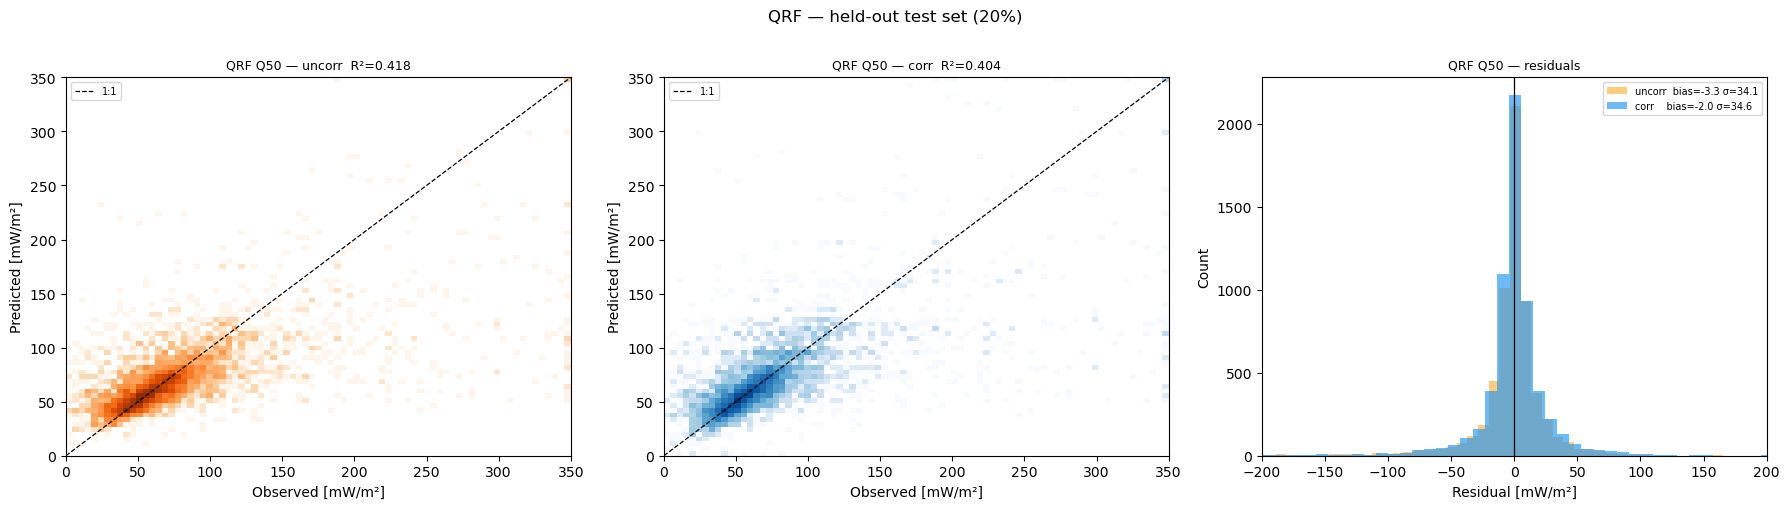

Saved fig/models/qrf_scatter_residuals.png


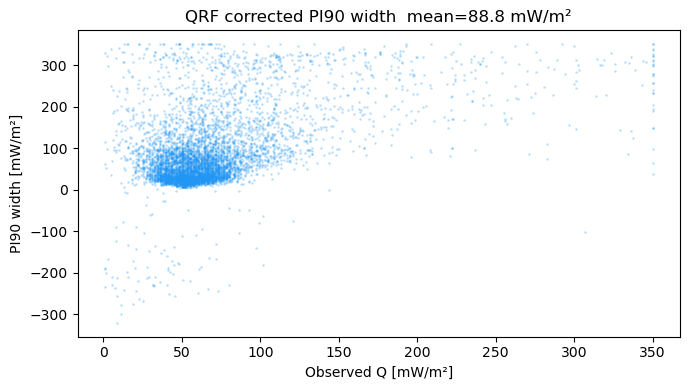

Saved fig/models/qrf_pi_width.png


In [15]:
scatter_residuals_fig(
    rows=[(y_te, qrf_q50, qrf_q50_corr, 'QRF Q50', '#2196F3')],
    suptitle='QRF — held-out test set (20%)',
    savepath=fig_dir / 'qrf_scatter_residuals.png',
)

# interval width vs observed
fig, ax = plt.subplots(figsize=(7, 4))
pi_width = (qrf_q95_corr - qrf_q05_corr) * 1e3
ax.scatter(y_te * 1e3, pi_width, s=1, alpha=0.2, c='#2196F3', rasterized=True)
ax.set_xlabel('Observed Q [mW/m²]'); ax.set_ylabel('PI90 width [mW/m²]')
ax.set_title(f'QRF corrected PI90 width  mean={pi_width.mean():.1f} mW/m²')
fig.tight_layout()
fig.savefig(fig_dir / 'qrf_pi_width.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show(); print(f'Saved {fig_dir}/qrf_pi_width.png')


## 10. Bundle artefacts for `5_TARGETS`

All objects needed for target-grid prediction bundled into a single
`qrf_artefacts.pkl`. `5_TARGETS` loads this with `pickle.load()`.

In [ ]:
artefacts = dict(
    model           = 'QRF',
    obs_sel         = obs_model,
    scaler          = scaler,
    qrf             = qrf,
    qrf_spline      = qrf_spline,        # ← correct name
    qhat_qrf        = float(qhat_qrf),
    QUANTILES       = QUANTILES,
    Q_CLIP_MIN      = Q_CLIP_MIN,
    q_clip_max      = float(q_clip_max),
    CONFORMAL_ALPHA = CONFORMAL_ALPHA,
    PARAMS          = QP,
)
bundle_path = model_dir / 'qrf_artefacts.pkl'
with open(bundle_path, 'wb') as fp:
    pickle.dump(artefacts, fp)
print(f'Bundle saved → {bundle_path}')
print('Keys:', list(artefacts.keys()))

NameError: name 'QP' is not defined

---

# Part 2 — 5a_QRF_TARGETS: Grid Prediction & netCDF Export


## 0. Config patch check

In [1]:
# ── config.py additions needed ───────────────────────────────────────────────
# Add these lines to config.py if not already present:
#
# MODEL_VERSION = '0_2'
#
# model_paths update — add Q25 and Q75 GBM:
# model_paths = {
#     'qrf'       : model_dir / 'qrf_model.pkl',
#     'gbm_q05'   : model_dir / 'gbm_q05_model.pkl',
#     'gbm_q25'   : model_dir / 'gbm_q25_model.pkl',
#     'gbm_q50'   : model_dir / 'gbm_q50_model.pkl',
#     'gbm_q75'   : model_dir / 'gbm_q75_model.pkl',
#     'gbm_q95'   : model_dir / 'gbm_q95_model.pkl',
#     'sim_correction': model_dir / 'sim_correction_spline.pkl',
#     'model_metrics' : model_dir / 'model_metrics.csv',
# }
#
# Each GBM artefact pkl is produced by 4b_GBM_MODEL for each quantile.
# The pkl must contain keys: 'model','scaler','spline','obs_sel','PARAMS'
print('Config note displayed.')


Config note displayed.


## 2. Helpers

In [3]:
# ── Grid loader ───────────────────────────────────────────────────────────────
def load_grid(grid_cfg, obs_sel):
    label, xcol, ycol = grid_cfg['label'], grid_cfg['x_col'], grid_cfg['y_col']
    df = pd.read_parquet(grid_cfg['parquet'])
    print(f'\n[{label.upper()}] {len(df):,} rows')
    missing = [f for f in obs_sel if f not in df.columns]
    if missing:
        warnings.warn(f'Missing features {missing} — filling NaN')
        for f in missing: df[f] = np.nan
    nan_cols = {f: int(df[f].isna().sum()) for f in obs_sel if df[f].isna().any()}
    if nan_cols: print(f'  NaN counts: {nan_cols}')
    else: print(f'  All {len(obs_sel)} features OK, no NaNs')
    x_vals = np.sort(df[xcol].unique()).astype(np.float64)
    y_vals = np.sort(df[ycol].unique()).astype(np.float64)
    nx, ny = len(x_vals), len(y_vals)
    is_reg = (len(df) == nx * ny)
    if is_reg:
        dx, dy = np.diff(x_vals), np.diff(y_vals)
        print(f'  Regular {ny}x{nx}  dx={dx[0]:.0f}m dy={dy[0]:.0f}m')
    else:
        print(f'  Irregular {len(df):,} pts (expected {ny*nx:,}) — griddata fallback')
    return df, x_vals, y_vals, ny, nx, is_reg

def build_X(df, obs_sel, scaler):
    X_raw  = df[obs_sel].values.astype(np.float32)
    finite = np.isfinite(X_raw).all(axis=1)
    X_sc   = np.full_like(X_raw, np.nan)
    if finite.any():
        X_sc[finite] = scaler.transform(X_raw[finite]).astype(np.float32)
    print(f'  finite points: {finite.sum():,} / {len(df):,}')
    return X_sc, finite

def to_2d(vals_1d, df, x_vals, y_vals, xcol, ycol, is_reg):
    ny, nx = len(y_vals), len(x_vals)
    if is_reg:
        tmp = df[[xcol, ycol]].copy()
        tmp['_v'] = vals_1d
        return tmp.pivot(index=ycol, columns=xcol, values='_v').values.astype(np.float32)
    from scipy.interpolate import griddata
    gx, gy = np.meshgrid(x_vals, y_vals)
    return griddata(df[[xcol, ycol]].values, vals_1d, (gx, gy), method='nearest').astype(np.float32)

def apply_spline(spline, vals):
    out = np.full(vals.shape, np.nan, dtype=np.float32)
    ok  = np.isfinite(vals)
    out[ok] = np.clip(spline(vals[ok]).astype(np.float32), q_clip_min, q_clip_max)
    return out

def shannon_H_norm(values_2d, bin_width=0.010):
    v = values_2d.ravel()
    v = v[np.isfinite(v)]
    if len(v) == 0: return np.nan
    bins = np.arange(q_clip_min, q_clip_max + bin_width, bin_width)
    counts, _ = np.histogram(v, bins=bins)
    p = counts / counts.sum()
    p = p[p > 0]
    H = float(scipy_entropy(p))
    H_max = float(np.log(len(bins) - 1))
    return round(H / H_max, 6) if H_max > 0 else 0.0

def make_ds(arrays, x_vals, y_vals, grid_cfg, params, obs_sel, model_tag, extra=None):
    coords = {'y': y_vals, 'x': x_vals}
    dvars = {name: xr.DataArray(arr, dims=['y','x'], coords=coords,
                                attrs={'units':'W m-2','long_name':name.replace('_',' ')})
             for name, arr in arrays.items()}
    ds = xr.Dataset(dvars, coords=coords)
    attrs = dict(
        title=f'{model_tag} heat-flow prediction',
        model=model_tag, version=MODEL_VERSION,
        institution=NETCDF_AUTHOR, Conventions=NETCDF_CONVENTIONS,
        crs=grid_cfg['crs'], epsg=str(grid_cfg['epsg']),
        region=grid_cfg['label'].upper(),
        created=datetime.datetime.utcnow().isoformat()+'Z',
        obs_sel=json.dumps(obs_sel),
        quantiles=json.dumps(QUANTILES),
        q_clip_min=float(q_clip_min), q_clip_max=float(q_clip_max),
        params_json=json.dumps(params, default=str),
    )
    if extra: attrs.update(extra)
    ds.attrs = attrs
    return ds

def save_nc(ds, path):
    enc = {v: {'zlib':True,'complevel':netcdf_compression_level,'dtype':'float32'}
           for v in ds.data_vars}
    ds.to_netcdf(path, encoding=enc)
    print(f'  Saved {path}  ({path.stat().st_size/1e6:.1f} MB)')

print('Helpers ready.')


Helpers ready.


## 3. Load QRF artefacts

In [5]:
## 3. Load QRF artefacts

with open(model_dir / 'qrf_artefacts.pkl', 'rb') as fp:
    art = pickle.load(fp)

qrf      = art['qrf']
scaler   = art['scaler']
spline   = art['qrf_spline']
obs_sel  = art['obs_sel']
PARAMS   = art['PARAMS']
qhat_qrf = art['qhat_qrf']

print(f'QRF loaded  n_estimators={qrf.n_estimators}  features={len(obs_sel)}')
print(f'obs_sel: {obs_sel}')
print(f'qhat_qrf: {qhat_qrf:.6f}')

QRF loaded  n_estimators=1000  features=21
obs_sel: ['MOHO', 'MOHO_GRAV', 'DEM', 'LAB', 'FREE_AIR', 'BOUGUER', 'SI', 'GEOID', 'REVEAL_S80', 'REVEAL_S90', 'REVEAL_S70', 'REVEAL_S100', 'REVEAL_VP60VS70', 'REVEAL_VP90VS60', 'REVEAL_VP50VS80', 'LITH_RHO', 'CRUST_RHO', 'MAG_SEIS_MOHO', 'SEDIMENT', 'CTD', 'EMAG2_LOG']
qhat_qrf: -0.003000


## 4. Predict & write netCDF

Loops over `TARGET_GRIDS` (ant + grl). For each:
1. Load parquet, verify features, check grid regularity
2. Scale features with train-fold scaler
3. Single `qrf.predict(X, quantiles=[...])` call
4. Apply Q50 spline correction, propagate offset to all quantiles
5. Compute IQR50, IQR90, σ
6. Reshape 1D → 2D (y, x)
7. Write compressed netCDF with metadata

In [ ]:

results_qrf = {}

for grid_cfg in TARGET_GRIDS:
    label = grid_cfg['label']
    prefix = 'Aq1_5' if label == 'ant' else 'Kq1_5'
    out_path = targets_dir / f'{prefix}_QRF_v{MODEL_VERSION}.nc'

    df, x_vals, y_vals, ny, nx, is_reg = load_grid(grid_cfg, obs_sel)
    X_sc, finite = build_X(df, obs_sel, scaler)
    xcol, ycol = grid_cfg['x_col'], grid_cfg['y_col']

    # ── QRF prediction (single pass, all quantiles) ──────────────────────
    print(f'  Predicting {len(df):,} points × {len(QUANTILES)} quantiles ...')
    t0 = time.time()
    q_preds = np.full((len(df), len(QUANTILES)), np.nan, dtype=np.float32)
    q_preds[finite] = qrf.predict(
        X_sc[finite], quantiles=QUANTILES
    ).astype(np.float32)
    print(f'  QRF predict wall time: {(time.time()-t0)/60:.1f} min')

    # ── clip to physical range ────────────────────────────────────────────
    q_preds = np.clip(q_preds, q_clip_min, q_clip_max)

    # ── spline correction on Q50; offsets for other quantiles ─────────────
    q50_raw  = q_preds[:, Q50_IDX]
    q50_corr = apply_spline(spline, q50_raw)
    offset   = q50_corr - q50_raw                 # additive shift

    arrays = {}
    qnames = ['q05','q25','q50','q75','q95']
    for qi, qn in enumerate(qnames):
        raw_1d  = q_preds[:, qi]
        corr_1d = np.clip(raw_1d + offset, q_clip_min, q_clip_max)
        arrays[f'qrf_{qn}_raw' ] = to_2d(raw_1d,  df, x_vals, y_vals, xcol, ycol, is_reg)
        arrays[f'qrf_{qn}_corr'] = to_2d(corr_1d, df, x_vals, y_vals, xcol, ycol, is_reg)

    # ── derived uncertainty metrics ───────────────────────────────────────
    iqr50_raw  = q_preds[:,3] - q_preds[:,1]          # Q75-Q25
    iqr90_raw  = q_preds[:,4] - q_preds[:,0]          # Q95-Q05
    sigma_raw  = iqr90_raw / (2 * 1.6449)             # Gaussian-equiv sigma
    iqr50_corr = np.clip(iqr50_raw + 0, 0, q_clip_max)  # offsets cancel in IQR
    iqr90_corr = np.clip(iqr90_raw + 0, 0, q_clip_max)
    sigma_corr = iqr90_corr / (2 * 1.6449)

    for name, arr1d in [
        ('qrf_iqr50_raw',  iqr50_raw),  ('qrf_iqr90_raw',  iqr90_raw),
        ('qrf_sigma_raw',  sigma_raw),
        ('qrf_iqr50_corr', iqr50_corr), ('qrf_iqr90_corr', iqr90_corr),
        ('qrf_sigma_corr', sigma_corr),
    ]:
        arrays[name] = to_2d(arr1d, df, x_vals, y_vals, xcol, ycol, is_reg)

    # ── Shannon entropy (normalised, scalar attribute) ────────────────────
    H_raw  = shannon_H_norm(arrays['qrf_q50_raw'])
    H_corr = shannon_H_norm(arrays['qrf_q50_corr'])
    print(f'  Shannon H (norm): raw={H_raw:.4f}  corr={H_corr:.4f}')

    # ── build & save dataset ──────────────────────────────────────────────
    ds = make_ds(arrays, x_vals, y_vals, grid_cfg, PARAMS, obs_sel,
                 model_tag=f'{prefix}_QRF',
                 extra={'shannon_H_q50_raw': H_raw,
                        'shannon_H_q50_corr': H_corr,
                        'spline_applied': 'Q50 only; other quantiles shifted by Q50 offset'})
    save_nc(ds, out_path)
    results_qrf[label] = ds
    print(f'  [{label.upper()}] done.')

print('\nAll QRF target grids complete.')



[ANT] 1,779,556 rows
  NaN counts: {'DEM': 383490}
  Regular 1334x1334  dx=5000m dy=5000m
  finite points: 1,396,066 / 1,779,556
  Predicting 1,779,556 points × 5 quantiles ...
  QRF predict wall time: 38.3 min
  Shannon H (norm): raw=0.3476  corr=0.3768
  Saved output/targets/Aq1_5_QRF_v0_2.nc  (51.4 MB)
  [ANT] done.

[GRL] 172,360 rows
  All 21 features OK, no NaNs
  Regular 556x310  dx=4950m dy=4950m
  finite points: 172,360 / 172,360
  Predicting 172,360 points × 5 quantiles ...
  QRF predict wall time: 16.3 min
  Shannon H (norm): raw=0.3835  corr=0.4119
  Saved output/targets/Kq1_5_QRF_v0_2.nc  (6.7 MB)
  [GRL] done.

All QRF target grids complete.


## 5. Summary statistics

In [7]:
for label, ds in results_qrf.items():
    print(f'\n[{label.upper()}] variables:')
    for v in ds.data_vars:
        arr = ds[v].values
        fin = arr[np.isfinite(arr)]
        print(f'  {v:30s}  mean={fin.mean()*1e3:.1f}  '
              f'std={fin.std()*1e3:.1f}  '
              f'[{fin.min()*1e3:.1f}, {fin.max()*1e3:.1f}] mW/m2')



[ANT] variables:
  qrf_q05_raw                     mean=23.8  std=5.2  [2.0, 40.0] mW/m2
  qrf_q05_corr                    mean=23.1  std=5.5  [1.0, 43.5] mW/m2
  qrf_q25_raw                     mean=41.8  std=5.4  [18.0, 81.3] mW/m2
  qrf_q25_corr                    mean=41.1  std=6.5  [12.4, 92.4] mW/m2
  qrf_q50_raw                     mean=56.7  std=8.5  [29.3, 128.0] mW/m2
  qrf_q50_corr                    mean=56.1  std=10.0  [23.2, 141.9] mW/m2
  qrf_q75_raw                     mean=75.3  std=16.9  [45.0, 238.0] mW/m2
  qrf_q75_corr                    mean=74.6  std=18.3  [38.8, 246.3] mW/m2
  qrf_q95_raw                     mean=134.4  std=61.3  [62.5, 350.0] mW/m2
  qrf_q95_corr                    mean=133.7  std=62.1  [60.6, 350.0] mW/m2
  qrf_iqr50_raw                   mean=33.5  std=14.8  [11.2, 181.1] mW/m2
  qrf_iqr90_raw                   mean=110.6  std=61.4  [38.0, 342.9] mW/m2
  qrf_sigma_raw                   mean=33.6  std=18.7  [11.6, 104.2] mW/m2
  qrf_iqr50_cor

In [ ]:
force_read_ant = True

if parquet_ant.exists() and not force_read_ant:
    print(f"Loading cached Antarctica grid from {parquet_ant}")
    ant_df = pd.read_parquet(parquet_ant)
    _ny = _nx = int(round(len(ant_df) ** 0.5))
    ant = Grid(
        lats=ant_df.lat.values, lons=ant_df.lon.values,
        x=ant_df.x.values, y=ant_df.y.values,
        verbose=False, regular_grid=(_ny, _nx),
        name="Antarctica", crs=3031,
        log_file=str(log_dir / "read_ant.log"),
    )
    for col in ant_df.columns:
        ant.df[col] = ant_df[col].values
    print(f"Loaded {len(ant.df):,} points, cols: {list(ant.df.columns)}")
else:
    with xr.open_dataset(bedmachine_antarctica_file) as bm:
        bm_x = bm['x'].values.copy()
        bm_y = bm['y'].values.copy()

    bm_res_m = 500
    step = grid_spacing_m_ant // bm_res_m
    ant_xs = bm_x[::step]
    ant_ys = bm_y[::step]
    XX, YY = np.meshgrid(ant_xs, ant_ys)
    ant_x = XX.ravel()
    ant_y = YY.ravel()
    ny_ant, nx_ant = XX.shape

    transformer = Transformer.from_crs(ant_crs, ref_crs, always_xy=True)
    ant_lon, ant_lat = transformer.transform(ant_x, ant_y)
    print(f'Antarctica grid: {len(ant_x):,} points  ({ny_ant} × {nx_ant})')

    ant = Grid(
        lats=ant_lat, lons=ant_lon, x=ant_x, y=ant_y,
        verbose=False, regular_grid=(ny_ant, nx_ant),
        name='Antarctica', crs=3031,
        log_file=str(log_dir / 'read_ant.log'),
    )


    print(f'  Columns: {list(ant.df.columns)}')

    ant.df.to_parquet(parquet_ant)
    print(f'  Cached to {parquet_ant}')



Antarctica grid: 1,779,556 points  (1334 × 1334)
  Columns: ['lon', 'lat', 'x', 'y']
  Cached to data/antarctica.parquet


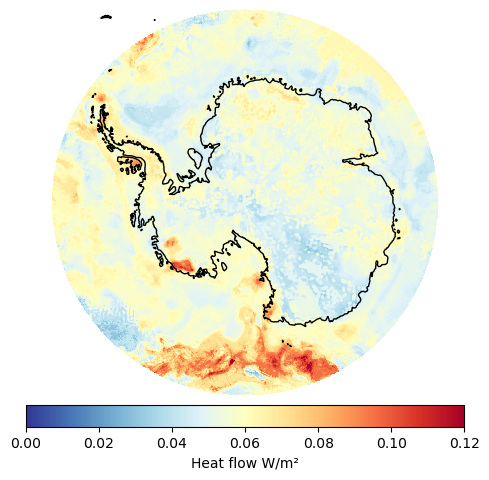

In [59]:
ant.df['qrf_q50_corr'] = results_qrf['ant']['qrf_q50_corr'].values[::-1].ravel()

fig, ax = ant.map(
    'qrf_q50_corr',
    cmap        = 'RdYlBu_r',
    vmin        = q_min,
    vmax        = 0.12,
    cbar        = True,
    cbar_title  = 'Heat flow',
    cbar_units_label = 'W/m²',
    coastlines  = True,
    show        = True,
    return_fig  = True,
)
#results_qrf['grl']['qrf_q50_corr'].plot(vmin = q_min, vmax = 0.12)

In [60]:
with xr.open_dataset(bedmachine_greenland_file) as bm:
    bm_x = bm['x'].values.copy()
    bm_y = bm['y'].values.copy()

bm_res_m = 150
step = grid_spacing_m_grl // bm_res_m   # = 33 for 5 km

grl_xs = bm_x[::step]
grl_ys = bm_y[::step]
XX, YY = np.meshgrid(grl_xs, grl_ys)
grl_x = XX.ravel()
grl_y = YY.ravel()
ny_grl, nx_grl = XX.shape

transformer_grl = Transformer.from_crs(grl_crs, ref_crs, always_xy=True)
grl_lon, grl_lat = transformer_grl.transform(grl_x, grl_y)
print(f'Greenland grid: {len(grl_x):,} points  ({ny_grl} × {nx_grl})')

grl = Grid(
    lats=grl_lat,
    lons=grl_lon,
    x=grl_x,
    y=grl_y,
    name="Greenland",  
    verbose=False,
    regular_grid=(ny_grl, nx_grl),
    crs=3413,
    log_file=str(log_dir / 'read_grl.log'),
)


grl.df.to_parquet(parquet_grl)
print(f'  Cached to {parquet_grl}')


Greenland grid: 172,360 points  (556 × 310)
  Cached to data/greenland.parquet


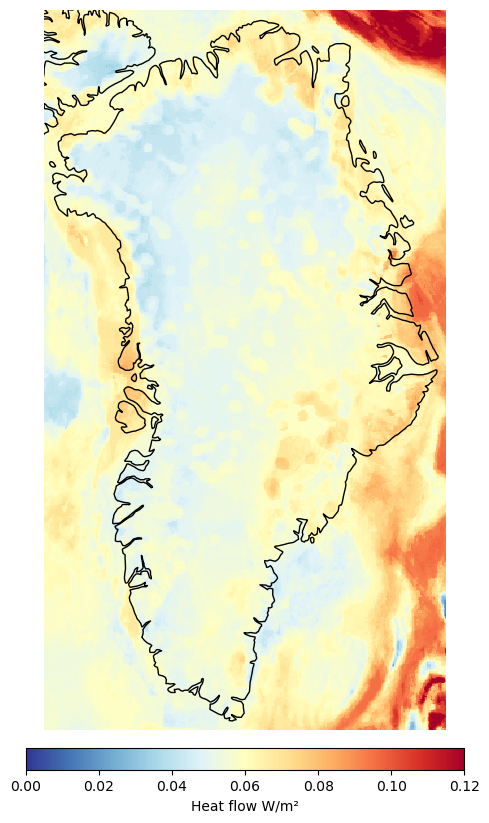

In [61]:
grl.df['qrf_q50_corr'] = results_qrf['grl']['qrf_q50_corr'].values[::-1].ravel()

fig, ax = grl.map(
    'qrf_q50_corr',
    cmap        = 'RdYlBu_r',
    vmin        = q_min,
    vmax        = 0.12,
    cbar        = True,
    cbar_title  = 'Heat flow',
    cbar_units_label = 'W/m²',
    coastlines  = True,
    show        = True,
    return_fig  = True,
)
#results_qrf['grl']['qrf_q50_corr'].plot(vmin = q_min, vmax = 0.12)